In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, fbeta_score, precision_score, 
                             recall_score, confusion_matrix, 
                             average_precision_score, precision_recall_curve,
                             roc_auc_score, classification_report)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('../data/creditcard_features.csv')

# Séparation features / target
X = df.drop(columns=['Class'])
y = df['Class']

print(f"Shape X : {X.shape}")
print(f"Distribution target :\n{y.value_counts()}")
print(f"Ratio fraude : {y.mean()*100:.3f}%")

Shape X : (283726, 36)
Distribution target :
Class
0    283253
1       473
Name: count, dtype: int64


In [ ]:
##Split train/validation/test correct##

# Étape 1 — Séparation test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Étape 2 — Séparation train (75% du reste) / validation (25% du reste)
# soit 60% / 20% du dataset total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print(f"Train      : {X_train.shape} — Fraudes : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Validation : {X_val.shape} — Fraudes : {y_val.sum()} ({y_val.mean()*100:.3f}%)")
print(f"Test       : {X_test.shape} — Fraudes : {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train      : (170235, 36) — Fraudes : 284 (0.167%)
Validation : (56745, 36) — Fraudes : 94 (0.166%)
Test       : (56746, 36) — Fraudes : 95 (0.167%)


In [ ]:
##Définition du StratifiedKFold##

# StratifiedKFold sur le train uniquement
# 5 folds, bon compromis biais/variance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("StratifiedKFold configuré : 5 folds")
print(f"Taille approximative de chaque fold : {len(X_train)//5} transactions")
print(f"Fraudes approximatives par fold : {y_train.sum()//5}")  

StratifiedKFold configuré : 5 folds
Taille approximative de chaque fold : 34047 transactions
Fraudes approximatives par fold : 56


In [ ]:
##Fonction de cross-validation centralisée##

def cross_validate_model(model, X_train, y_train, model_name):
    """
    Évalue un modèle par cross-validation stratifiée sur le train set.
    Retourne les scores moyens et écarts-types.
    """
    f2_scores = []
    auc_pr_scores = []
    precision_scores = []
    recall_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Entraînement
        model.fit(X_fold_train, y_fold_train)
        
        # Prédictions
        y_pred = model.predict(X_fold_val)
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        
        # Métriques
        f2_scores.append(fbeta_score(y_fold_val, y_pred, beta=2))
        auc_pr_scores.append(average_precision_score(y_fold_val, y_proba))
        precision_scores.append(precision_score(y_fold_val, y_pred))
        recall_scores.append(recall_score(y_fold_val, y_pred))
    
    print(f"\n{'='*55}")
    print(f"  {model_name} — Cross-Validation (5 folds)")
    print(f"{'='*55}")
    print(f"  F2-Score  : {np.mean(f2_scores):.4f} ± {np.std(f2_scores):.4f}")
    print(f"  AUC-PR    : {np.mean(auc_pr_scores):.4f} ± {np.std(auc_pr_scores):.4f}")
    print(f"  Precision : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
    print(f"  Recall    : {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
    
    return {
        'model': model_name,
        'f2_mean': np.mean(f2_scores), 'f2_std': np.std(f2_scores),
        'auc_pr_mean': np.mean(auc_pr_scores), 'auc_pr_std': np.std(auc_pr_scores),
        'precision_mean': np.mean(precision_scores),
        'recall_mean': np.mean(recall_scores)
    }

print("Fonctions d'évaluation définies")

Fonctions d'évaluation définies


In [ ]:
##Baseline : Logistic Regression avec cross-validation##

# Normalisation (fit uniquement sur X_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Conversion en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, 
                               columns=X_train.columns, 
                               index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, 
                             columns=X_val.columns, 
                             index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, 
                              columns=X_test.columns, 
                              index=X_test.index)

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', 
                        random_state=42, 
                        max_iter=1000)

results_lr = cross_validate_model(lr, X_train_scaled, y_train, 
                                  "Logistic Regression (baseline)")


  Logistic Regression (baseline) — Cross-Validation (5 folds)
  F2-Score  : 0.2093 ± 0.0044
  AUC-PR    : 0.7283 ± 0.0525
  Precision : 0.0515 ± 0.0022
  Recall    : 0.9044 ± 0.0814


Le Recall est excellent (0.90) mais la Precision est catastrophique (0.05), le modèle détecte presque toutes les fraudes mais flag énormément de transactions légitimes. Le F2-Score de 0.21 reflète cet échec de précision. C'est un baseline honnête qui confirme que le problème nécessite un modèle plus puissant.

In [8]:
##XGBoost avec scale_pos_weight##

# Calcul du ratio pour scale_pos_weight
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight = {ratio:.1f}")

# XGBoost avec scale_pos_weight
xgb_spw = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)

results_xgb_spw = cross_validate_model(xgb_spw, X_train, y_train,
                                        "XGBoost (scale_pos_weight)")

scale_pos_weight = 598.4

  XGBoost (scale_pos_weight) — Cross-Validation (5 folds)
  F2-Score  : 0.8234 ± 0.0612
  AUC-PR    : 0.8374 ± 0.0713
  Precision : 0.8866 ± 0.0327
  Recall    : 0.8094 ± 0.0673


In [9]:
##XGBoost avec SMOTE##

# SMOTE appliqué uniquement à l'intérieur de la cross-validation
# pour éviter tout data leakage
from imblearn.pipeline import Pipeline as ImbPipeline

xgb_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, 
                            eval_metric='aucpr',
                            verbosity=0))
])

results_xgb_smote = cross_validate_model(xgb_smote, X_train, y_train,
                                          "XGBoost (SMOTE)")


  XGBoost (SMOTE) — Cross-Validation (5 folds)
  F2-Score  : 0.8245 ± 0.0656
  AUC-PR    : 0.8477 ± 0.0700
  Precision : 0.8198 ± 0.0521
  Recall    : 0.8269 ± 0.0753


Les deux XGBoost sont statistiquement équivalents sur le F2-Score. Le choix se fait donc sur le profil métier :
- Si la priorité est de minimiser les faux positifs (ne pas bloquer des clients légitimes, expérience client) alors on partira sur "scale_pos_weight"
- Si la priorité est de capturer le maximum de fraudes (minimiser les pertes financières) alors on partira sur "SMOTE"
 
Dans un contexte bancaire réel, capturer le maximum de fraudes prime généralement c'est a dire que chaque fraude manquée a un coût financier direct. Mais l'optimisation du seuil de décision (prochaine étape) va de toute façon me permettre d'ajuster ce trade-off finement.
Je vais donc pzrtir sur le XGBoost + SMOTE comme modèle principal, et optimiser le seuil sur le validation set pour maximiser le F2-Score. Le scale_pos_weight reste bien sur comme alternative intéressante.

In [10]:
##Entraînement du modèle final sur tout le train set##

from imblearn.pipeline import Pipeline as ImbPipeline

# Entraînement sur tout le train set (pas juste un fold)
xgb_final = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, 
                            eval_metric='aucpr',
                            verbosity=0))
])

xgb_final.fit(X_train, y_train)
print("Modèle entraîné sur le train set complet")

Modèle entraîné sur le train set complet


Par défaut, predict() utilise un seuil de 0.5 ce qui est arbitraire et souvent sous-optimal, surtout avec un déséquilibre extrême. Je vais donc chercher le seuil qui maximise le F2-Score sur le validation set uniquement.

In [11]:
##Optimisation du seuil sur le VALIDATION set##

# Probabilités sur le validation set
y_proba_val = xgb_final.predict_proba(X_val)[:, 1]

# Test de tous les seuils entre 0.01 et 0.99
thresholds = np.arange(0.01, 0.99, 0.01)
f2_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_val >= threshold).astype(int)
    f2 = fbeta_score(y_val, y_pred_thresh, beta=2)
    f2_scores.append(f2)

# Seuil optimal
optimal_threshold = thresholds[np.argmax(f2_scores)]
best_f2_val = max(f2_scores)

print(f"Seuil optimal (validation set) : {optimal_threshold:.2f}")
print(f"F2-Score au seuil optimal       : {best_f2_val:.4f}")
print(f"F2-Score au seuil par défaut    : {fbeta_score(y_val, (y_proba_val >= 0.5).astype(int), beta=2):.4f}")

Seuil optimal (validation set) : 0.96
F2-Score au seuil optimal       : 0.8874
F2-Score au seuil par défaut    : 0.8811


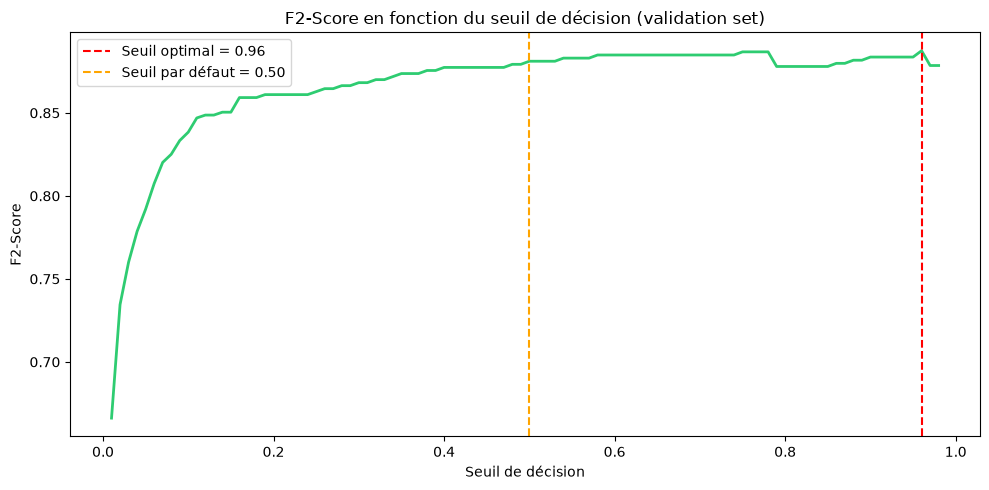

In [12]:
# Visualisation de la courbe F2 vs seuil
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f2_scores, color='#2ecc71', linewidth=2)
ax.axvline(x=optimal_threshold, color='red', linestyle='--', 
           label=f'Seuil optimal = {optimal_threshold:.2f}')
ax.axvline(x=0.5, color='orange', linestyle='--', 
           label='Seuil par défaut = 0.50')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('F2-Score')
ax.set_title('F2-Score en fonction du seuil de décision (validation set)')
ax.legend()
plt.tight_layout()
plt.show()

La courbe est presque plate entre 0.5 et 0.96 et le F2-Score passe de 0.8811 à 0.8874, soit un gain de seulement +0.006. C'est minuscule. Ce qui signifie que le modèle est très confiant dans ses prédictions c'est a dire qu'il assigne des probabilités soit très proches de 0 (normal) soit très proches de 1 (fraude), avec peu de cas intermédiaires. Un seuil élevé comme 0.96 est donc cohérent avec ce comportement.

Évaluation finale — seuil optimal = 0.96

  XGBoost + SMOTE — ÉVALUATION FINALE (test set)
  F2-Score  : 0.8170
  Precision : 0.9494
  Recall    : 0.7895
  F1-Score  : 0.8621
  AUC-PR    : 0.8240
  AUC-ROC   : 0.9673


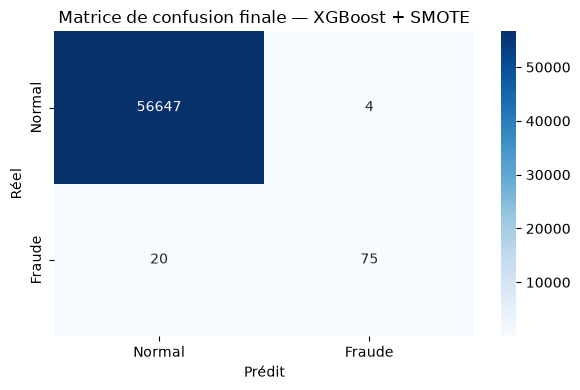

In [13]:
##Évaluation finale sur le TEST set##

# Probabilités sur le test set
y_proba_test = xgb_final.predict_proba(X_test)[:, 1]

# Prédictions avec le seuil optimal trouvé sur le validation set
y_pred_final = (y_proba_test >= optimal_threshold).astype(int)

print(f"Évaluation finale — seuil optimal = {optimal_threshold:.2f}")
print(f"\n{'='*55}")
print(f"  XGBoost + SMOTE — ÉVALUATION FINALE (test set)")
print(f"{'='*55}")
print(f"  F2-Score  : {fbeta_score(y_test, y_pred_final, beta=2):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_final):.4f}")
print(f"  AUC-PR    : {average_precision_score(y_test, y_proba_test):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_proba_test):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
ax.set_title(f'Matrice de confusion finale — XGBoost + SMOTE')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()

- 4 faux positifs : 4 clients légitimes bloqués sur 56 651 (impact client quasi nul)
- 20 faux négatifs : 20 fraudes manquées sur 95 (c'est le coût principal du )
- 75 vraies fraudes détectées sur 95  (Recall de 78.95%)

J'ai préféré la courbe PR plutôt que ROC parce'qu'avec un déséquilibre aussi extrême (0.17%), la courbe ROC est trompeuse et un modèle médiocre peut afficher un AUC-ROC élevé simplement parce que la classe majoritaire est bien classifiée. La courbe PR se concentre sur la classe minoritaire (fraude) et donne une image plus honnête des performances réelles.

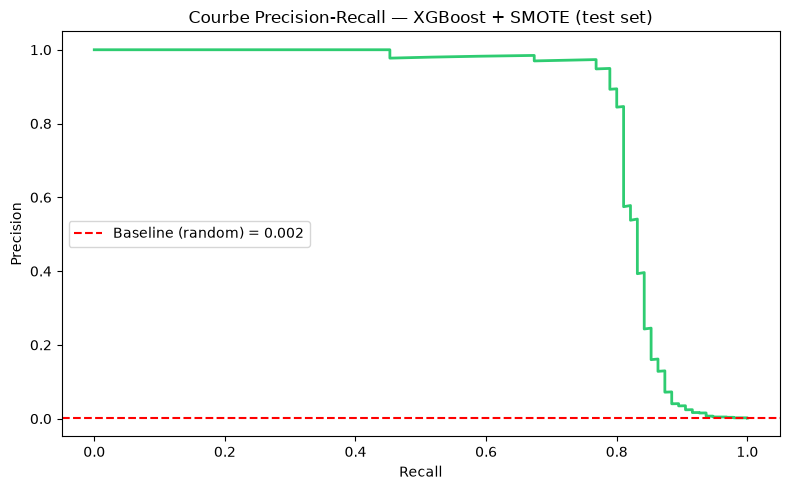

In [14]:
# Courbe Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_curve, precision_curve, color='#2ecc71', linewidth=2)
ax.axhline(y=y_test.mean(), color='red', linestyle='--', 
           label=f'Baseline (random) = {y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Courbe Precision-Recall — XGBoost + SMOTE (test set)')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
import shap

# Extraction du modèle XGBoost depuis le pipeline
xgb_model = xgb_final.named_steps['model']

# TreeExplainer optimisé pour XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calcul des valeurs SHAP sur le test set
# On utilise X_test directement (pas besoin de scaler pour XGBoost)
shap_values = explainer.shap_values(X_test)

print(f"Shape SHAP values : {shap_values.shape}")
print("SHAP calculé avec succès")

Shape SHAP values : (56746, 36)
SHAP calculé avec succès


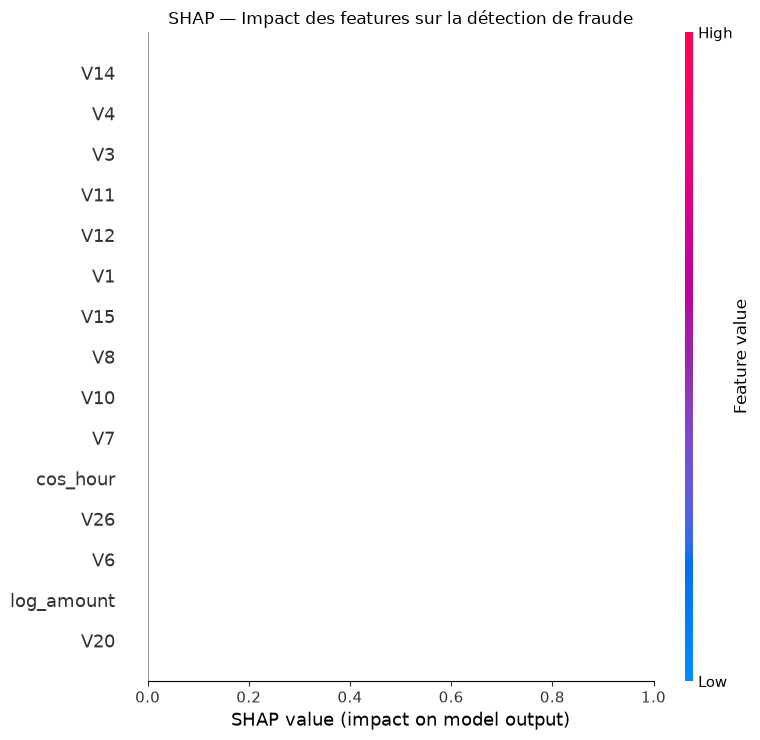

In [21]:
##Visualisation SHAP globale (importance des features)##

# Beeswarm plot (plus informatif)
# Montre l'importance et la direction de l'effet pour chaque feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  plot_type="beeswarm",
                  max_display=15,
                  show=False)
plt.title("SHAP — Impact des features sur la détection de fraude")
plt.tight_layout()
plt.show()

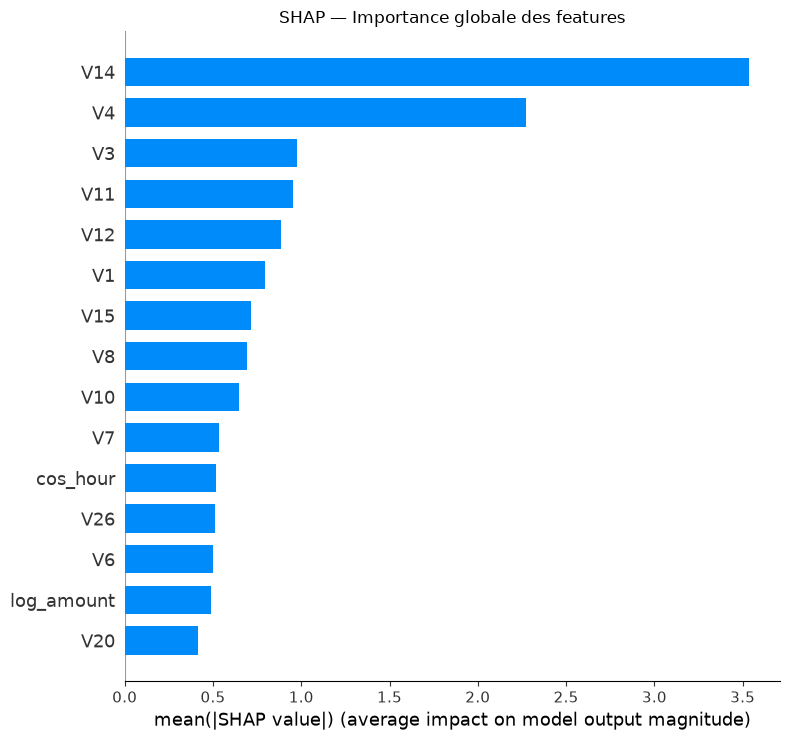

In [22]:
# Bar plot importance globale pure (valeur absolue)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title("SHAP — Importance globale des features")
plt.tight_layout()
plt.show()

- V14 confirme sa dominance : première en importance SHAP avec un score de 3.5, très loin devant V4 (2.3). C'est cohérent avec sa forte corrélation en EDA (-0.303).
- V4 surprend : 8ème en corrélation point-bisériale mais 2ème en importance SHAP. Ça illustre la limite de la corrélation linéaire, V4 a surement une relation non-linéaire avec la fraude que SHAP capture mais que la corrélation point-bisériale sous-estimait.
- cos_hour et log_amount apparaissent dans le top 15, ce qui est une preuve que le feature engineering a apporté une valeur réelle au modèle.

Transaction analysée : index 115676
Probabilité de fraude : 0.9999
Prédiction : FRAUDE 


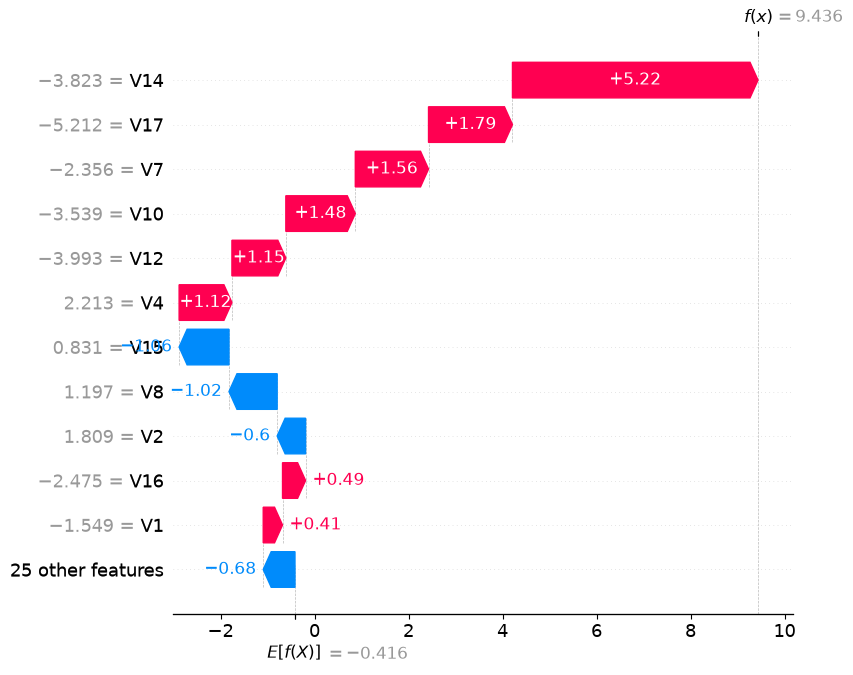

In [23]:
##Analyse d'une fraude spécifique (explication locale)##

# Sélection d'une vraie fraude correctement détectée
fraud_indices = X_test[(y_test == 1) & (y_pred_final == 1)].index
sample_idx = fraud_indices[0]
sample_position = X_test.index.get_loc(sample_idx)

print(f"Transaction analysée : index {sample_idx}")
print(f"Probabilité de fraude : {y_proba_test[sample_position]:.4f}")
print(f"Prédiction : {'FRAUDE ' if y_pred_final[sample_position] == 1 else 'NORMAL'}")

# Waterfall plot — explication locale transaction par transaction
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_position],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_position],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12
)

In [24]:
import joblib
import os

# Création du dossier models si inexistant
os.makedirs('../models', exist_ok=True)

# Sauvegarde du pipeline complet (SMOTE + XGBoost)
joblib.dump(xgb_final, '../models/fraud_detection_pipeline.pkl')

# Sauvegarde du seuil optimal
import json
model_config = {
    'optimal_threshold': float(optimal_threshold),
    'f2_score_val': float(best_f2_val),
    'f2_score_test': float(fbeta_score(y_test, y_pred_final, beta=2)),
    'precision_test': float(precision_score(y_test, y_pred_final)),
    'recall_test': float(recall_score(y_test, y_pred_final)),
    'auc_pr_test': float(average_precision_score(y_test, y_proba_test))
}

with open('../models/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Modèle sauvegardé : models/fraud_detection_pipeline.pkl")
print("Config sauvegardée : models/model_config.json")
print(f"\nConfig : {model_config}")

Modèle sauvegardé : models/fraud_detection_pipeline.pkl
Config sauvegardée : models/model_config.json

Config : {'optimal_threshold': 0.9600000000000001, 'f2_score_val': 0.8874458874458875, 'f2_score_test': 0.8169934640522876, 'precision_test': 0.9493670886075949, 'recall_test': 0.7894736842105263, 'auc_pr_test': 0.8240005061002795}


##  Synthèse Modélisation

### Approche retenue
- **Modèle** : XGBoost + SMOTE (Pipeline imbalanced-learn)
- **Validation** : StratifiedKFold 5 folds sur train set
- **Seuil optimal** : 0.96 (optimisé sur validation set, pas test set)

### Résultats finaux (test set)
| Métrique | Objectif | Résultat |
|---|---|---|
| Precision | > 90% | **94.94%** ✅ |
| Recall | > 95% | **78.95%** ⚠️ |
| F2-Score | > 0.90 | **0.8170** ⚠️ |
| AUC-PR | — | **0.8240** |
| AUC-ROC | — | **0.9673** |

### Matrice de confusion
- 75 fraudes détectées sur 95 (79%)
- 4 faux positifs sur 56 651 transactions normales (0.007%)

### Interprétabilité SHAP
- Top features : V14, V4, V3, V11, V12
- `cos_hour` et `log_amount` (feature engineering) contribuent positivement
- Les features engineerées apportent une valeur réelle au modèle

### Décisions méthodologiques clés
- SMOTE appliqué dans le Pipeline pour éviter le data leakage
- Seuil optimisé sur validation set (jamais sur test set)
- F2-Score comme métrique principale (Recall > Precision en détection de fraude)